#### Combining the data from trials, and adding some missing columns for ease of use

In [2]:
possible_dw_values = [12, 4, 9, 3, 6, 2, 3, 1, 14, 2, 7, 1, 3.5, 0.5, 1.75, 0.25, 15, 1, 11.25, 0.75, 7.5, 0.5, 3.75, 0.25]

def closest(val, lst):
    return min(lst, key=lambda x: abs(x - val))

In [3]:
import pandas as pd
import glob
import os

PPI = 96

folder_path = "./trials"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Sort files by creation time
csv_files.sort(key=os.path.getctime)

dfs = []
for idx, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file)

    # adding some missing infotmation to the table here

    # to keep it same as in excel sheet
    subject_id = (idx + 1) // 2
    
    df["subject_id"] = subject_id
    df["group_id"] = (subject_id + 1) % 2 

    if file.lower().endswith("touchscreen.csv"):
        df["device"] = 0
    else:
        df["device"] = 1

    # Sketchy fix for my mistake, we saved pixels during trials not inches, sorry ;D
    df["D"] = df["D"].apply(lambda x: closest(x / PPI * 2.54, possible_dw_values))
    df["W"] = df["W"].apply(lambda x: closest(x / PPI * 2.54, possible_dw_values))


    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

output_path = "all_trials.csv"
final_df.to_csv(output_path, index=False)

#### Helpers

In [4]:
conditions = [
    (12, 4), (9, 3), (6, 2), (3, 1),                    # difficulty 2
    (14, 2), (7, 1), (3.5, 0.5), (1.75, 0.25),          # difficulty 3
    (15, 1), (11.25, 0.75), (7.5, 0.5), (3.75, 0.25)    # difficulty 4
]

difficulty_map = [2]*4 + [3]*4 + [4]*4

cond_df = pd.DataFrame(conditions, columns=["D", "W"])
cond_df["difficulty_id"] = difficulty_map


def create_summary(df, group_id=-1):
    if group_id != -1:
        df = df[df["group_id"] == group_id].copy()

    grouped_mean_df = (
        df
        .groupby(["D", "W"]).agg(MT_mean=("MT", "mean"), error_rate=("error", "mean"))
        .reset_index()
    )
        
    merged = grouped_mean_df.merge(cond_df, on=["D","W"], how="left")
    
    merged = merged[["D", "W", "difficulty_id", "MT_mean", "error_rate"]]
    return merged


def create_device_summary(df):
    # deivce, D, W, mean_MT, error_rate

    grouped_mean_df = (
        df
        .groupby(["device", "D", "W"]).agg(MT_mean=("MT", "mean"), error_rate=("error", "mean"))
        .reset_index()
    )

    merged = grouped_mean_df.merge(cond_df, on=["D","W"], how="left")

    merged["device_name"] = merged["device"].map({0: "Touchscreen", 1: "Touchpad"})

    merged = merged[["device", "device_name", "D", "W", "difficulty_id", "MT_mean", "error_rate"]]
    return merged


In [51]:
# id, device, difficulty index, mean time 

def create_subjects_summary(df):
    grouped_subjects_df = (
        df
        .groupby(["subject_id", "group_id", "device", "D", "W"]).agg(MT_mean=("MT", "mean"), error_rate=("error", "mean"))
        .reset_index()
    )    

    merged = grouped_subjects_df.merge(cond_df, on=["D","W"], how="left")

    merged = merged[["subject_id", "group_id", "device", "difficulty_id", "MT_mean", "error_rate"]]

    merged["device_name"] = merged["device"].map({0: "Touchscreen", 1: "Touchpad"})

    return merged


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_device_summary(df):
    plt.figure(figsize=(8,5))
    
    sns.lmplot(
        data=df,
        x="difficulty_id",
        y="MT_mean",
        hue="device_name",
        palette="viridis",
        height=6,
        aspect=1.3,
        scatter_kws={"s": 100},
        ci=95,
    )

    plt.xlabel("Difficulty")
    plt.ylabel("Mean Movement Time (ms)")
    plt.title("Mean Movement Time vs Difficulty per Device (with Regression & 95% CI)")
    plt.show()

    sns.lmplot(
        data=df,
        x="difficulty_id",
        y="error_rate",
        hue="device_name",
        palette="viridis",
        height=6,
        aspect=1.3,
        scatter_kws={"s": 100},
        ci=95,
    )

    plt.xlabel("Difficulty")
    plt.ylabel("Error Rate")
    plt.title("Error Rate vs Difficulty per Device (with Regression & 95% CI)")
    plt.show()    


In [39]:

def plot_summary(df):
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x="difficulty_id",
        y="MT_mean",
        hue="difficulty_id",
        palette="viridis",
        s=100
    )
    plt.xlabel("Difficulty")
    plt.ylabel("Mean Movement Time (ms)")
    plt.title("Mean Movement Time vs Difficulty")
    plt.legend(title="Difficulty")
    plt.show()
    
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x="difficulty_id",
        y="error_rate",
        hue="difficulty_id",
        palette="viridis",
        s=100
    )
    plt.xlabel("Difficulty")
    plt.ylabel("Error Rate")
    plt.title("Error Rate vs Difficulty")
    plt.ylim(0,1)
    plt.legend(title="Difficulty")
    plt.show()
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df,
        x="D",
        y="W",
        hue="difficulty_id",
        palette="viridis",
        s=200
    )
    plt.xlabel("D (cm)")
    plt.ylabel("W (cm)")
    plt.title("Conditions: D vs W colored by Difficulty")
    plt.legend(title="Difficulty")
    plt.show()

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_groups(df):
    plt.figure(figsize=(10, 6))
    
    sns.swarmplot(
        data=df,
        x="group_id",
        y="MT_mean",
        hue="difficulty_id",
        dodge=True,
        palette="viridis",
        size=6,
        alpha=0.8
    )
    
    plt.xlabel("Group")
    plt.ylabel("Mean Movement Time (ms)")
    plt.title("Distribution of Mean Movement Time by Group and Difficulty")
    plt.legend(title="Difficulty", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()  


In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_groups_violin(df):

    # unique_devices = df['device'].unique()  
    device_palette = {"Touchscreen": "lightgreen", "Touchpad": "lightblue"} 

    # df["device"] = df["device"].astype(str)

    g = sns.FacetGrid(
        df,
        col="difficulty_id",
        col_wrap=2,
        height=5,
        sharey=True
    )

    g.map_dataframe(
        sns.violinplot,
        x="group_id",
        y="MT_mean",
        hue="device_name",
        dodge=False,
        palette=device_palette, 
        inner=None,
        alpha=0.3
    )
    
    g.map_dataframe(
        sns.swarmplot,
        x="group_id",
        y="MT_mean",
        hue="device_name",
        dodge=False,
        palette=device_palette, 
        size=6,
        alpha=0.8
    )

    for ax in g.axes.flat:
        if ax.legend_:
            ax.legend_.remove()
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.margins(x=0.2)

    g.add_legend(title="Device")
    
    g.set_axis_labels("Group", "Mean Movement Time (ms)")
    g.set_titles("Difficulty ID: {col_name}")
    
    plt.subplots_adjust(top=0.9, wspace=0.4)
    g.fig.suptitle("Mean Movement Time by Group and Device per Difficulty", fontsize=14)
    plt.show()

### Per Device

In [7]:
all_trials = pd.read_csv("./all_trials.csv")
device_summary = create_device_summary(all_trials)
device_summary

,device,device_name,D,W,difficulty_id,MT_mean,error_rate
0,0,Touchscreen,1.75,0.25,3,646.550170,0.854545
1,0,Touchscreen,3.00,1.00,2,562.438037,0.254545
2,0,Touchscreen,3.50,0.50,3,595.228043,0.763636
3,0,Touchscreen,3.75,0.25,4,662.392902,0.909091
4,0,Touchscreen,6.00,2.00,2,529.524036,0.018182
5,0,Touchscreen,7.00,1.00,3,604.630076,0.345455
6,0,Touchscreen,7.50,0.50,4,630.708746,0.781818
7,0,Touchscreen,9.00,3.00,2,532.017305,0.000000
8,0,Touchscreen,11.25,0.75,4,654.791819,0.454545
9,0,Touchscreen,12.00,4.00,2,538.204193,0.018182


In [54]:
summary = create_subjects_summary(all_trials)
summary


,subject_id,group_id,device,difficulty_id,MT_mean,error_rate,device_name
0,1,0,0,3,608.753538,0.8,Touchscreen
1,1,0,0,2,580.937433,0.2,Touchscreen
2,1,0,0,3,606.277466,1.0,Touchscreen
3,1,0,0,4,568.128300,1.0,Touchscreen
4,1,0,0,2,502.064657,0.0,Touchscreen
...,...,...,...,...,...,...,...
271,12,1,1,2,881.443930,0.0,Touchpad
272,12,1,1,4,1133.993578,0.2,Touchpad
273,12,1,1,2,995.489740,0.0,Touchpad
274,12,1,1,3,988.284159,0.0,Touchpad


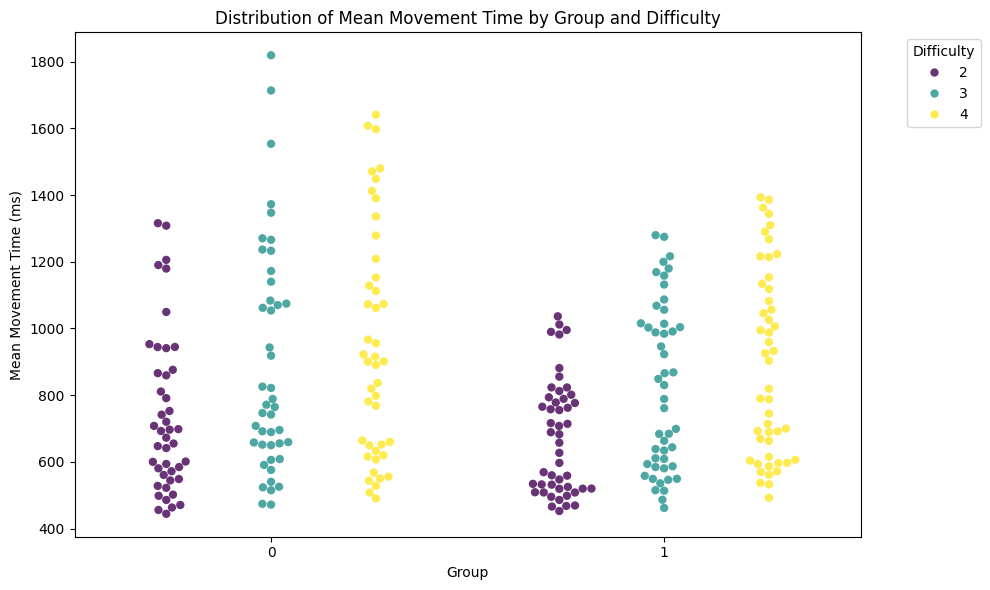

In [16]:
plot_groups(summary)

/var/folders/qk/lqmmvwx17l73rlcrp052p9ph0000gn/T/ipykernel_72286/3572628120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/var/folders/qk/lqmmvwx17l73rlcrp052p9ph0000gn/T/ipykernel_72286/3572628120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


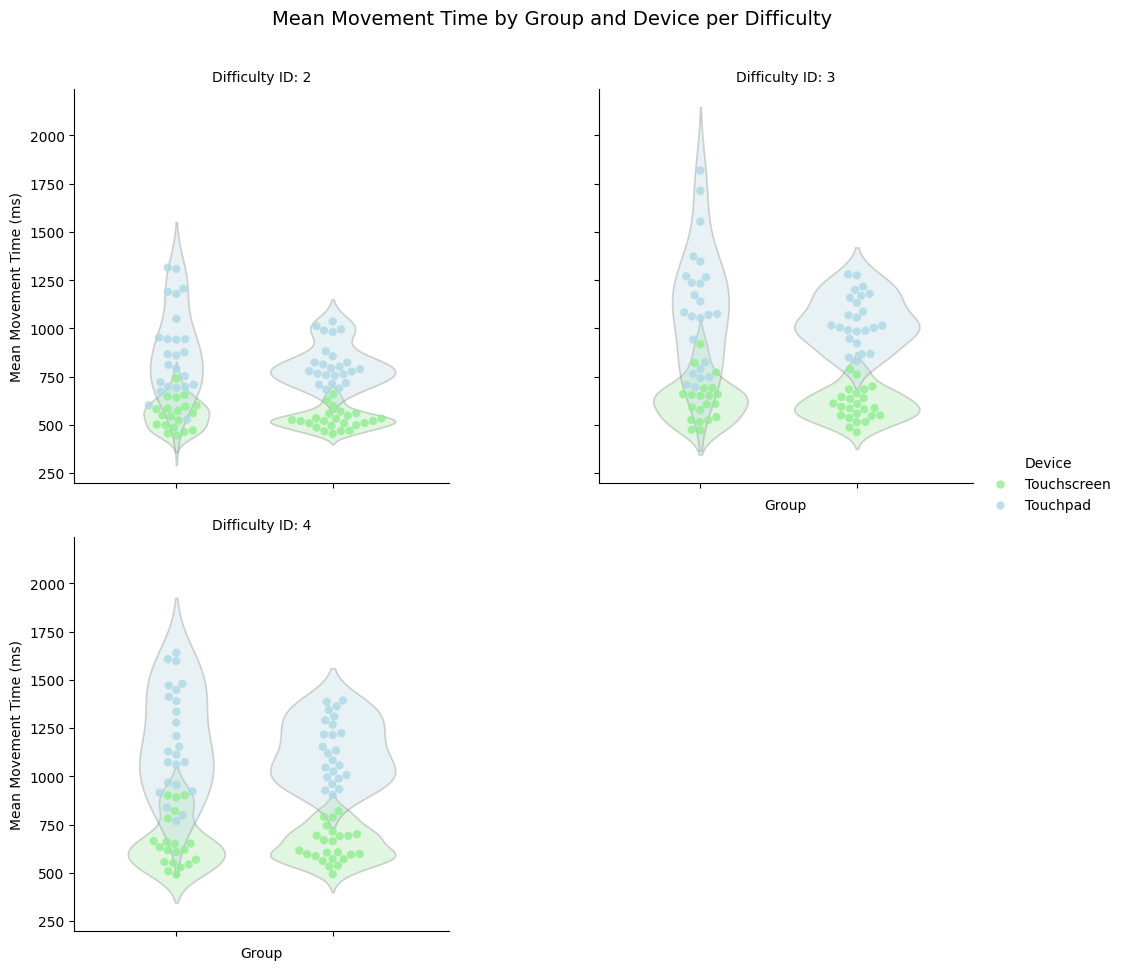

In [86]:
plot_groups_violin(summary)

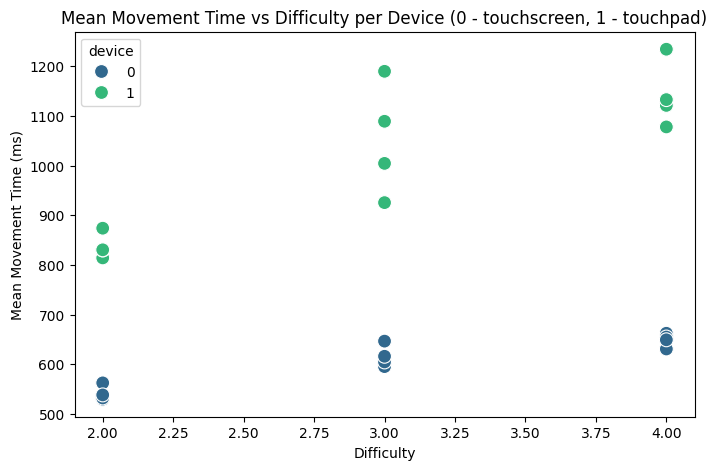

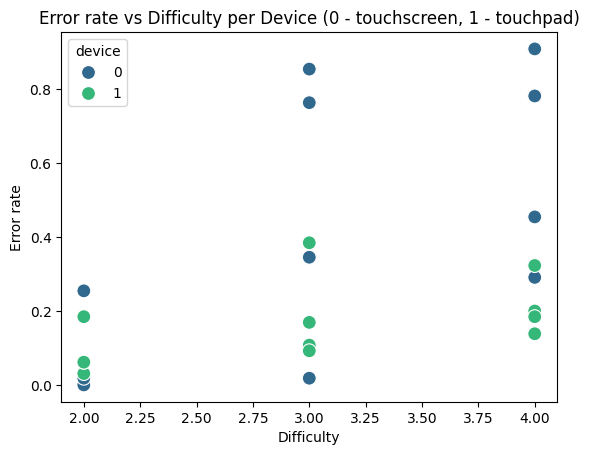

In [6]:
plot_device_summary(device_summary)

### Groups combined

In [11]:
all_trials = pd.read_csv("./all_trials.csv")

combined_summary = create_summary(all_trials)
combined_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,940.967284,0.600000
1,3.00,1.00,2,731.206681,0.216667
2,3.50,0.50,3,862.917467,0.441667
3,3.75,0.25,4,972.321413,0.591667
4,6.00,2.00,2,683.720718,0.025000
5,7.00,1.00,3,821.277761,0.216667
6,7.50,0.50,4,896.490596,0.466667
7,9.00,3.00,2,693.544483,0.033333
8,11.25,0.75,4,884.053063,0.308333
9,12.00,4.00,2,696.518938,0.041667


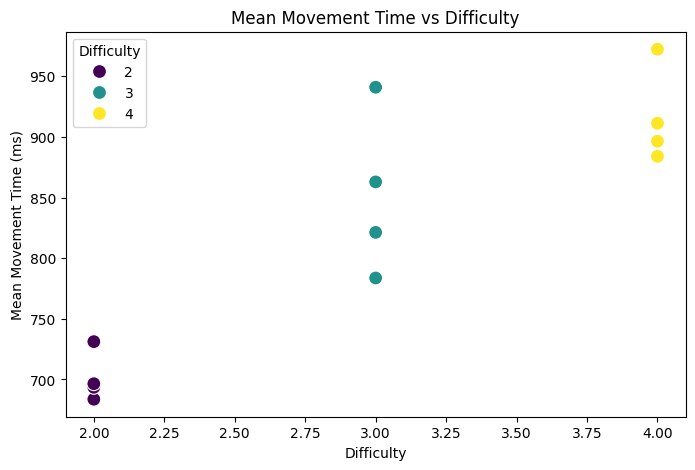

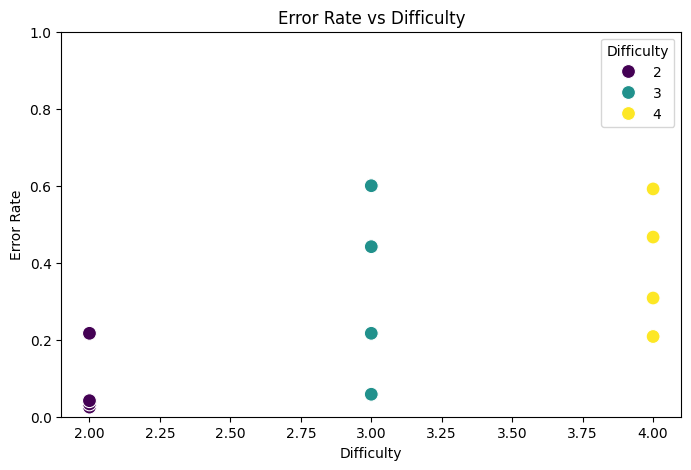

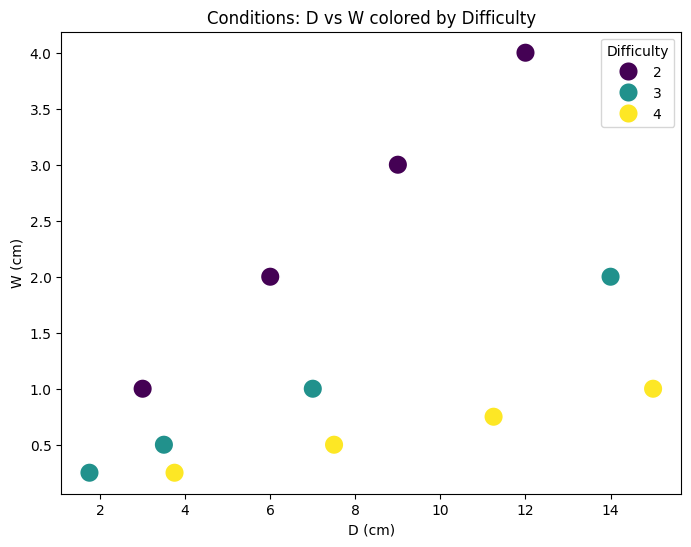

In [80]:
plot_summary(combined_summary)

#### Group 0

In [81]:
group_0_summary = create_summary(all_trials, 0)
group_0_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,974.980871,0.566667
1,3.00,1.00,2,761.897326,0.133333
2,3.50,0.50,3,891.203050,0.483333
3,3.75,0.25,4,961.873357,0.633333
4,6.00,2.00,2,700.300634,0.016667
5,7.00,1.00,3,842.692753,0.216667
6,7.50,0.50,4,923.663700,0.400000
7,9.00,3.00,2,706.165473,0.033333
8,11.25,0.75,4,927.904379,0.233333
9,12.00,4.00,2,744.174902,0.050000


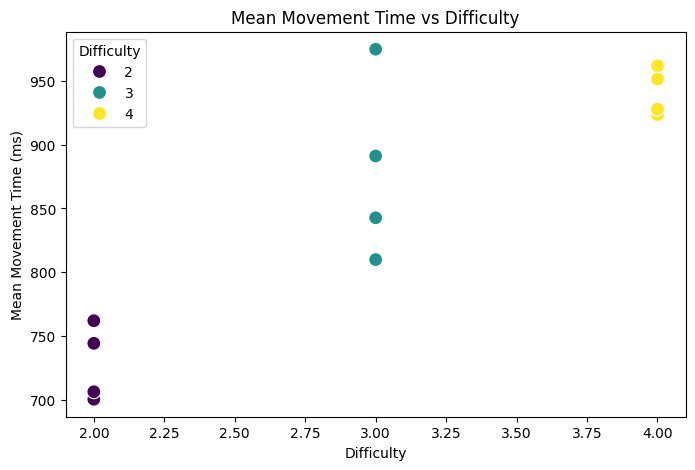

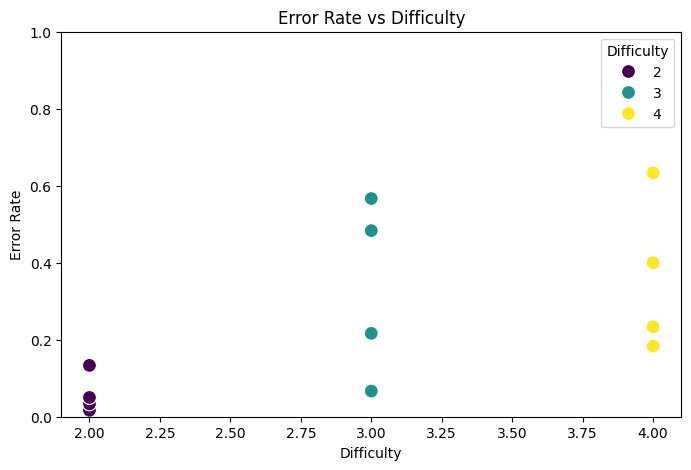

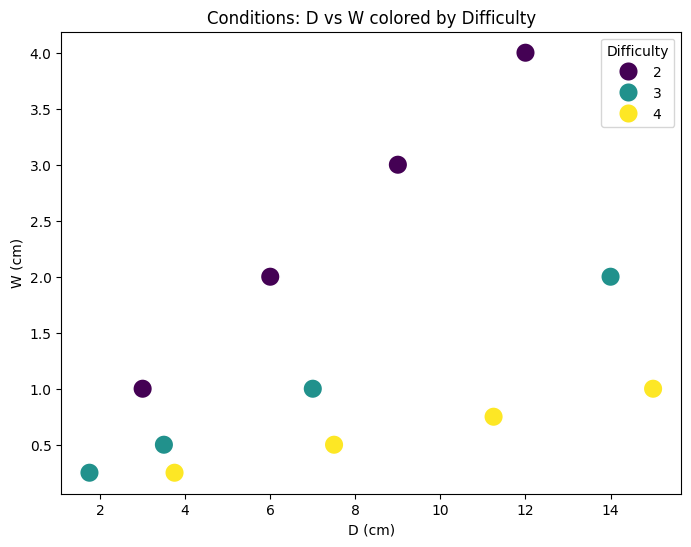

In [82]:
plot_summary(group_0_summary)

#### Group 1

In [83]:
group_1_summary = create_summary(all_trials, 1)
group_1_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,906.953696,0.633333
1,3.00,1.00,2,700.516037,0.300000
2,3.50,0.50,3,834.631884,0.400000
3,3.75,0.25,4,982.769469,0.550000
4,6.00,2.00,2,667.140802,0.033333
5,7.00,1.00,3,799.862770,0.216667
6,7.50,0.50,4,869.317492,0.533333
7,9.00,3.00,2,680.923494,0.033333
8,11.25,0.75,4,840.201747,0.383333
9,12.00,4.00,2,648.862974,0.033333


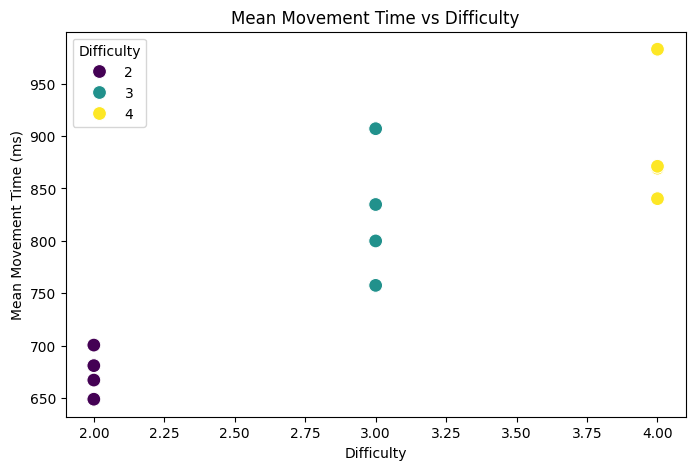

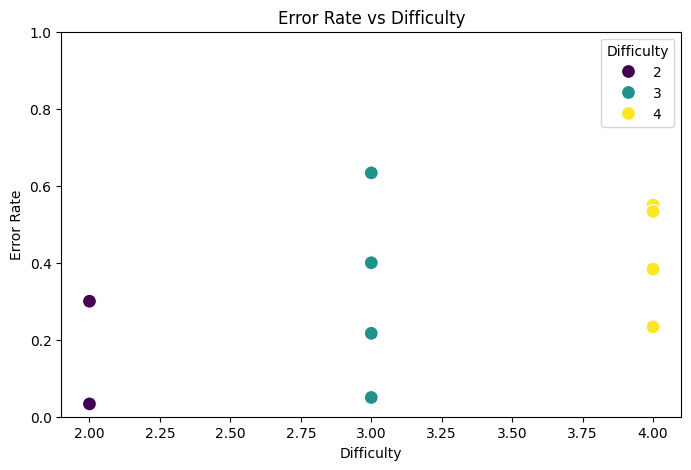

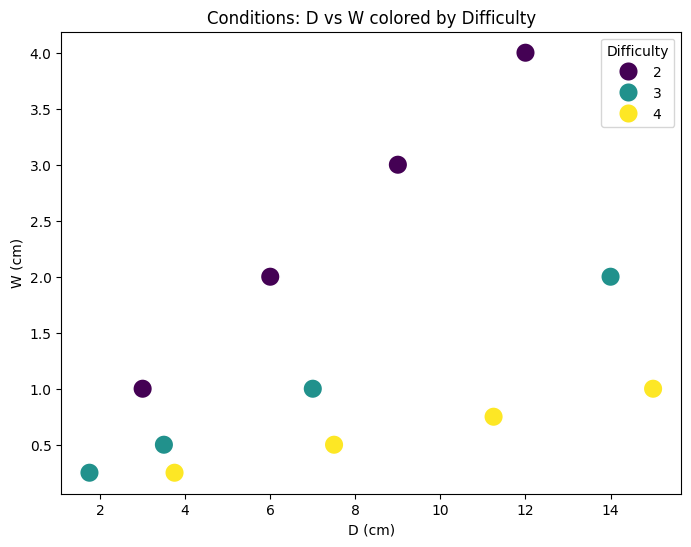

In [84]:
plot_summary(group_1_summary)

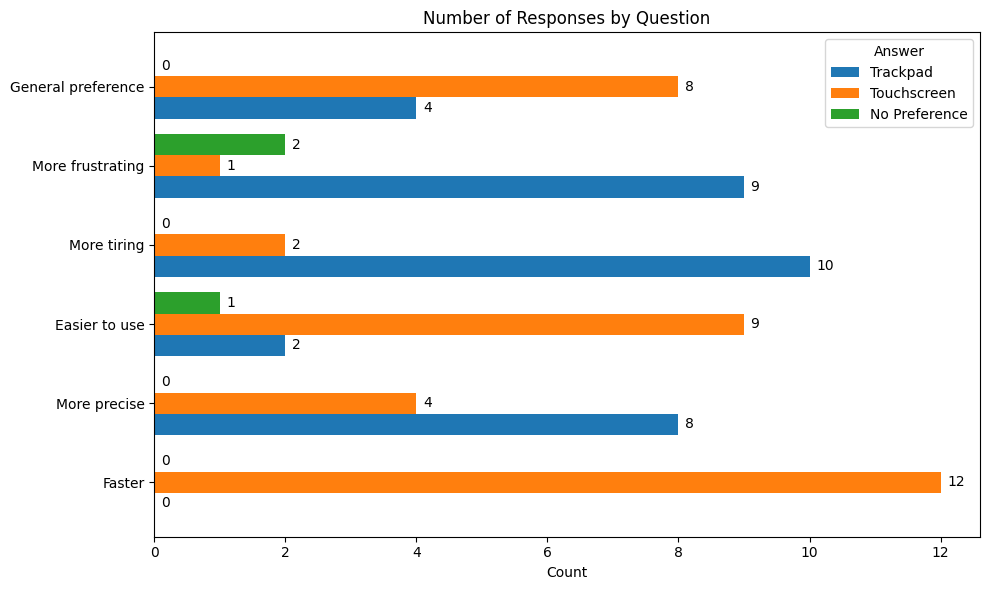

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('questions.csv')

questions = ["faster","more precise","easier to use","more tiring","more frustrating","general preference"]

answer_map = {
    0: 'No Preference',
    1: 'Trackpad',
    2: 'Touchscreen'
}

for q in questions:
    df[q] = df[q].map(answer_map)

answer_options = ['Trackpad', 'Touchscreen', 'No Preference']

grouped_values = {q: df[q].value_counts().reindex(answer_options, fill_value=0) for q in questions}

y_pos = np.arange(len(questions))
bar_height = 0.8 / len(answer_options)  

fig, ax = plt.subplots(figsize=(10, 6))

for i, ans in enumerate(answer_options):
    counts = [grouped_values[q][ans] for q in questions]
    ax.barh(y_pos - 0.4 + i*bar_height + bar_height/2, counts, height=bar_height, label=ans)

ax.set_yticks(y_pos)
ax.set_yticklabels([q.capitalize() for q in questions])
ax.set_xlabel('Count')
ax.set_title('Number of Responses by Question')
ax.legend(title='Answer')

for i, ans in enumerate(answer_options):
    counts = [grouped_values[q][ans] for q in questions]
    for j, val in enumerate(counts):
        ax.text(val + 0.1, y_pos[j] - 0.4 + i*bar_height + bar_height/2, str(val), va='center')

plt.tight_layout()
plt.show()


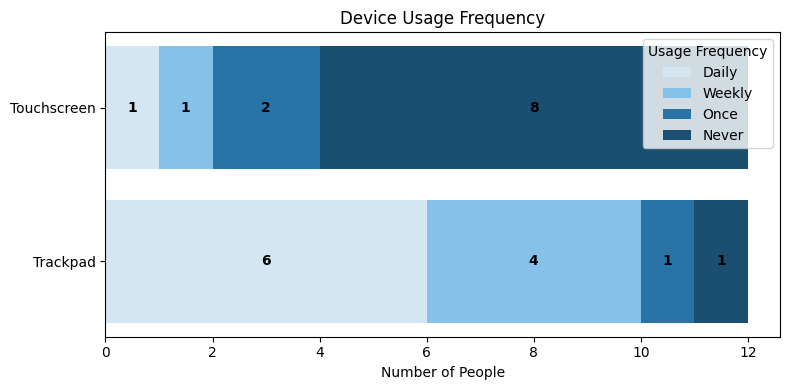

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('questions.csv') 

usage_columns = ['trackpad_usage', 'touchscreen_usage']
devices = ['Trackpad', 'Touchscreen']

usage_map = {1: 'Daily', 2: 'Weekly', 3: 'Once', 4: 'Never'}
usage_levels = [1, 2, 3, 4] 

usage_counts = {device: df[col].value_counts().reindex(usage_levels, fill_value=0) 
                for device, col in zip(devices, usage_columns)}

y_pos = np.arange(len(devices))

bottom = np.zeros(len(devices))

colors = ['#d4e6f1', '#85c1e9', '#2874a6', '#1b4f72'] 

fig, ax = plt.subplots(figsize=(8, 4))

for i, level in enumerate(usage_levels):
    counts = [usage_counts[device][level] for device in devices]
    ax.barh(y_pos, counts, left=bottom, color=colors[i], label=usage_map[level])
    
    for j, val in enumerate(counts):
        if val > 0:
            ax.text(bottom[j] + val/2, y_pos[j], str(val), va='center', ha='center', color='black', fontweight='bold')
    
    bottom += counts 

ax.set_yticks(y_pos)
ax.set_yticklabels(devices)
ax.set_xlabel('Number of People')
ax.set_title('Device Usage Frequency')
ax.legend(title='Usage Frequency')

plt.tight_layout()
plt.show()
